Error downloading image: Status code 429


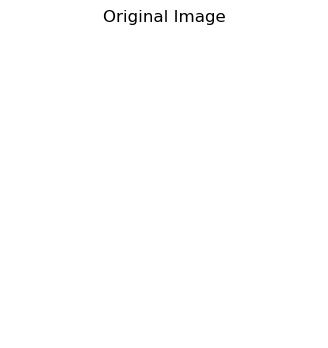

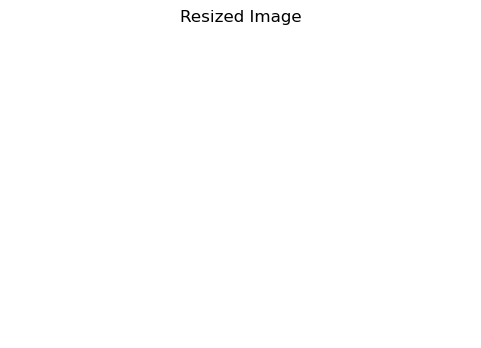

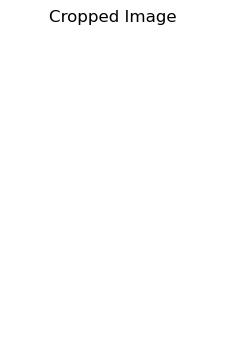

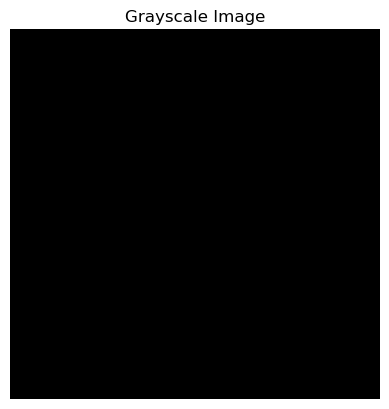

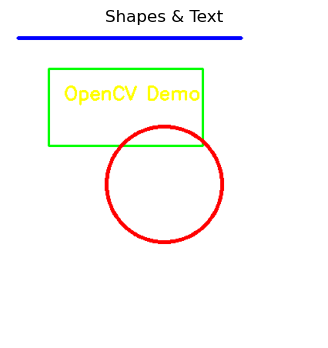

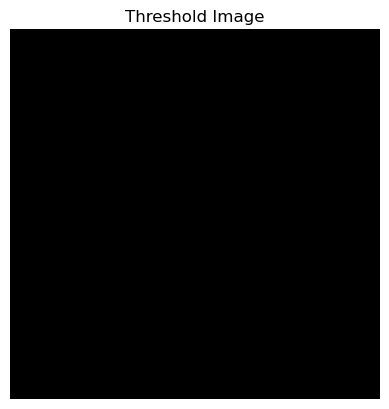

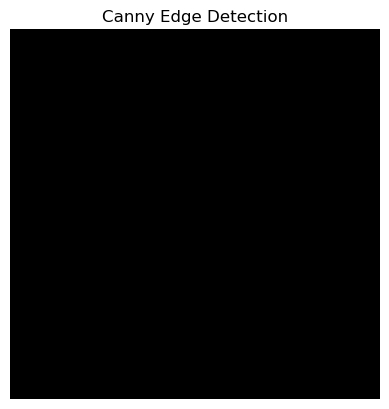

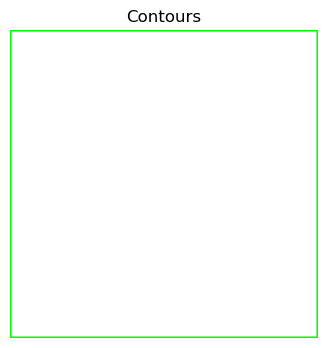

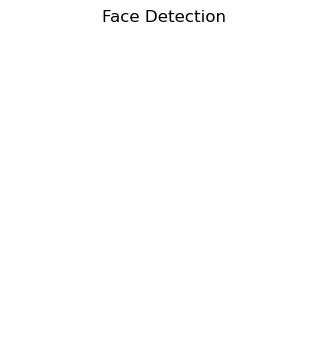

True

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import requests
import os

def show_image(img, title="Image"):
    if img is None:
        print(f"Error: Image not loaded for {title}")
        return
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    plt.figure(figsize=(6,4))
    plt.imshow(img_rgb)
    plt.title(title)
    plt.axis('off')
    plt.show()

# -----------------------------
# Download sample image safely
# -----------------------------
img_url = "https://upload.wikimedia.org/wikipedia/commons/3/3f/Fronalpstock_big.jpg"
img_path = "sample_image.jpg"

if not os.path.exists(img_path):
    headers = {'User-Agent': 'Mozilla/5.0'}
    r = requests.get(img_url, headers=headers)
    if r.status_code == 200:
        with open(img_path, 'wb') as f:
            f.write(r.content)
    else:
        print(f"Error downloading image: Status code {r.status_code}")

image = cv2.imread(img_path)
if image is None:
    image = 255 * np.ones((400, 400, 3), dtype=np.uint8)  # fallback image

show_image(image, "Original Image")

# Resize & Crop
resized_img = cv2.resize(image, (300, 200))
cropped_img = image[100:400, 200:500]
show_image(resized_img, "Resized Image")
show_image(cropped_img, "Cropped Image")

# Grayscale
gray_img = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
plt.imshow(gray_img, cmap='gray')
plt.title("Grayscale Image")
plt.axis('off')
plt.show()

# Drawing Shapes
shapes_img = image.copy()
cv2.line(shapes_img, (10,10), (300,10), (255,0,0), 3)
cv2.rectangle(shapes_img, (50,50), (250,150), (0,255,0), 2)
cv2.circle(shapes_img, (200,200), 75, (0,0,255), 3)
cv2.putText(shapes_img, "OpenCV Demo", (70,90), cv2.FONT_HERSHEY_SIMPLEX, 0.8, (0,255,255), 2)
show_image(shapes_img, "Shapes & Text")

# Thresholding
_, thresh_img = cv2.threshold(gray_img, 127, 255, cv2.THRESH_BINARY)
plt.imshow(thresh_img, cmap='gray')
plt.title("Threshold Image")
plt.axis('off')
plt.show()

# Edge Detection
edges_img = cv2.Canny(gray_img, 100, 200)
plt.imshow(edges_img, cmap='gray')
plt.title("Canny Edge Detection")
plt.axis('off')
plt.show()

# Contours
contour_img = image.copy()
contours, _ = cv2.findContours(thresh_img, cv2.RETR_TREE, cv2.CHAIN_APPROX_SIMPLE)
cv2.drawContours(contour_img, contours, -1, (0,255,0), 2)
show_image(contour_img, "Contours")

# Face Detection
face_cascade = cv2.CascadeClassifier(cv2.data.haarcascades + "haarcascade_frontalface_default.xml")
faces = face_cascade.detectMultiScale(gray_img, scaleFactor=1.1, minNeighbors=5)
face_img = image.copy()
for (x,y,w,h) in faces:
    cv2.rectangle(face_img, (x,y), (x+w, y+h), (255,0,0), 2)
show_image(face_img, "Face Detection")

# Save processed images
cv2.imwrite("resized_image.jpg", resized_img)
cv2.imwrite("cropped_image.jpg", cropped_img)
cv2.imwrite("shapes_image.jpg", shapes_img)
cv2.imwrite("threshold_image.jpg", thresh_img)
cv2.imwrite("edges_image.jpg", edges_img)
cv2.imwrite("contours_image.jpg", contour_img)
cv2.imwrite("face_detected.jpg", face_img)